In [7]:
from ijson.common import is_iterable
%matplotlib inline
%load_ext autoreload
%autoreload 2

from pathlib import Path
import numpy as np
from Utils.rfmap import load_rf_maps, RFMapList, asrfmap, plot_2d_rfmap
from Utils.plotting import apply_light_plot_style
from scipy.ndimage import gaussian_filter
from matplotlib import pyplot as plt

apply_light_plot_style()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
base_dir: Path = Path("/mnt/senzailab/Kai/#Recording/m20/")
date = 260918

sessionID = 2
probeList = ("A",)
targetProbe = "A"
rf_time_range = (0.0, 0.2)
# cluster_forming_z = 1.5

is_rotation: bool = True
is_save = True

session_dir = base_dir / str(date)
hd_session = session_dir / f"{date}_9"
rf_session = session_dir / f"{date}_{sessionID}"
rf_data_path = rf_session / "data"
save_path = rf_data_path / "rfmapping"

In [9]:
rf_maps_by_probe = {}
summed_rf_maps_by_probe = {}
rf_centers_by_probe = {}
rfs_by_probe = {}

for probe in probeList:
    probe_dir = (
        rf_session
        / "data/rfmapping/good/-100_400_1ms"
        / f"Probe{probe}"
    )
    rf_files = sorted(probe_dir.glob("*.rfmap"))

    if len(rf_files) == 1:
        rf_source_path = rf_files[0]
    else:
        prefix = "rotation_30" if is_rotation else "regular"
        rf_source_path = (
            probe_dir / f"{prefix}_unitsSpikeCounts_{date}_{sessionID}.rfmap"
        )
        if not rf_source_path.is_file():
            raise FileNotFoundError(f"Requested RF file not found: {rf_source_path}")


    raw = load_rf_maps(rf_source_path)
    summed = raw.sum(*rf_time_range)
    # Existing QC: this drops a unit if any pooled spatial bin is zero.
    zero_unit_offsets = np.unique(summed.where(0)[0])
    keep_unit_mask = np.ones(summed.n_units, dtype=bool, )
    keep_unit_mask[zero_unit_offsets] = False

    excluded_unit_ids = np.asarray(summed.unit_ids)[zero_unit_offsets]
    raw = RFMapList([rf_map for rf_map, keep in zip(
        raw, keep_unit_mask, strict=True, ) if keep], raw.source_path, )

    summed = RFMapList([rf_map for rf_map, keep in zip(
        summed, keep_unit_mask, strict=True, ) if keep], summed.source_path, )

    print(f"Kept {summed.n_units} in Probe{probe}")

    result_path = rf_source_path.with_suffix(".npz")
    result = summed.rf_2d(
        is_shuffle=False,
        cluster_forming_z=1.8,
        result_path=result_path,
    )
    with np.load(result_path, allow_pickle=False) as saved:
        center = saved["center_2d"]

    rf_maps_by_probe[probe] = raw
    summed_rf_maps_by_probe[probe] = summed
    rfs_by_probe[probe] = result
    rf_centers_by_probe[probe] = center

rf_all = np.concatenate(
    [rfs_by_probe[probe] for probe in probeList],
    axis=0,
)

center_all = np.concatenate(
    [rf_centers_by_probe[probe] for probe in probeList],
    axis=0,
)

# Keep probe identity because unit IDs may overlap between probes.
RFunitPool = [
    (probe, unit_id)
    for probe in probeList
    for unit_id in rf_maps_by_probe[probe].unit_ids
]

print({probe: rfs_by_probe[probe].shape[0] for probe in probeList})

has_rf = np.any(center_all, axis=(1, 2))

units_with_rf = [
    RFunitPool[i] for i in np.flatnonzero(has_rf)
]

print(units_with_rf)  # [(probe, unit_id), ...]
num_neurons_with_rf = int(has_rf.sum())
if is_save:
    np.save(rf_source_path.parent / "units_with_rf.npy", units_with_rf)
print(num_neurons_with_rf)

Sum: 100%|██████████| 327/327 [00:00<00:00, 12510.49unit/s]

Kept 83 in ProbeA
{'A': 83}
[('A', 10), ('A', 13), ('A', 20), ('A', 131), ('A', 273), ('A', 276), ('A', 278), ('A', 323), ('A', 505), ('A', 842), ('A', 1177)]
11


In [10]:
"""target_unitID = 267
target_maps = summed_rf_maps_by_probe[targetProbe]
target_unit = target_maps.by_unit_id(target_unitID)
target_unit_index = target_maps.unit_ids.index(target_unitID)

target_unit_bump = rfs_by_probe[targetProbe][
    target_unit_index
]
target_unit_bump_x = np.any(target_unit_bump, axis=0).astype(np.uint8)

plot_2d_rfmap(target_unit.to_2d_array(), cmap="grey")

plot_2d_rfmap(target_unit_bump, cmap="grey")"""

'target_unitID = 267\ntarget_maps = summed_rf_maps_by_probe[targetProbe]\ntarget_unit = target_maps.by_unit_id(target_unitID)\ntarget_unit_index = target_maps.unit_ids.index(target_unitID)\n\ntarget_unit_bump = rfs_by_probe[targetProbe][\n    target_unit_index\n]\ntarget_unit_bump_x = np.any(target_unit_bump, axis=0).astype(np.uint8)\n\nplot_2d_rfmap(target_unit.to_2d_array(), cmap="grey")\n\nplot_2d_rfmap(target_unit_bump, cmap="grey")'

(A, 10)


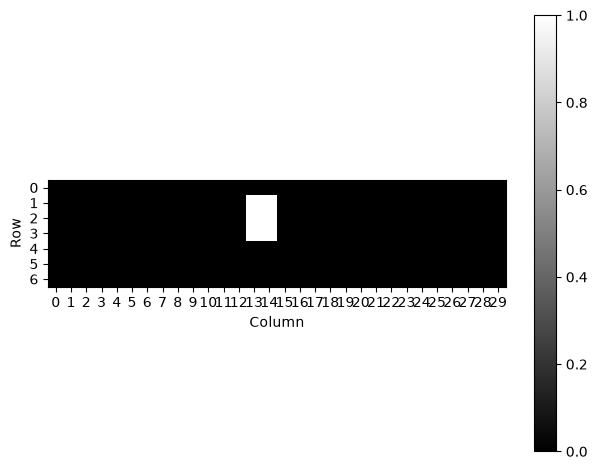

(A, 13)


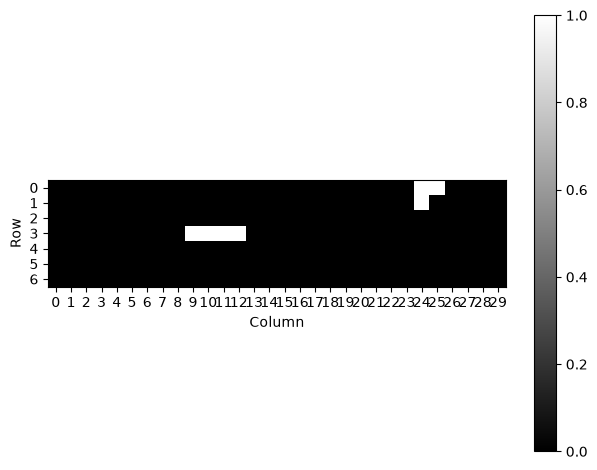

(A, 20)


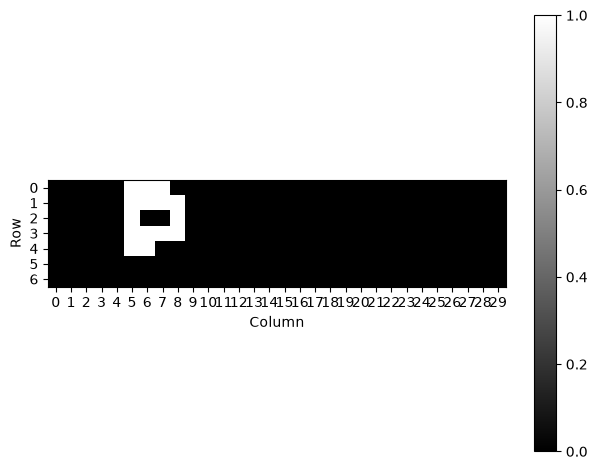

(A, 30)


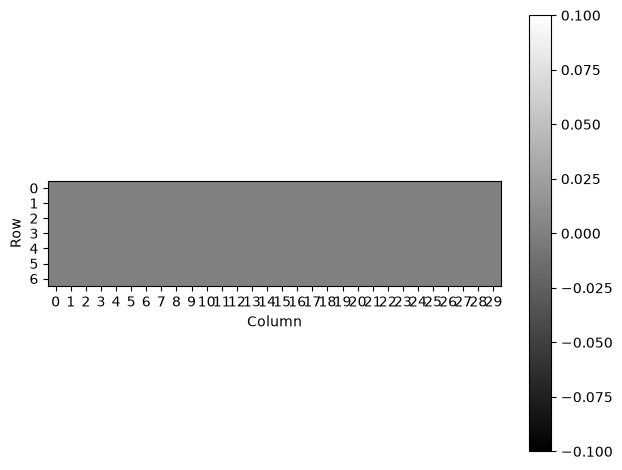

(A, 85)


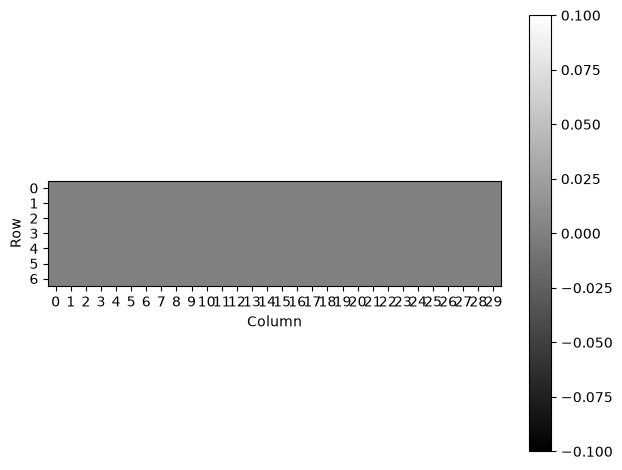

(A, 116)


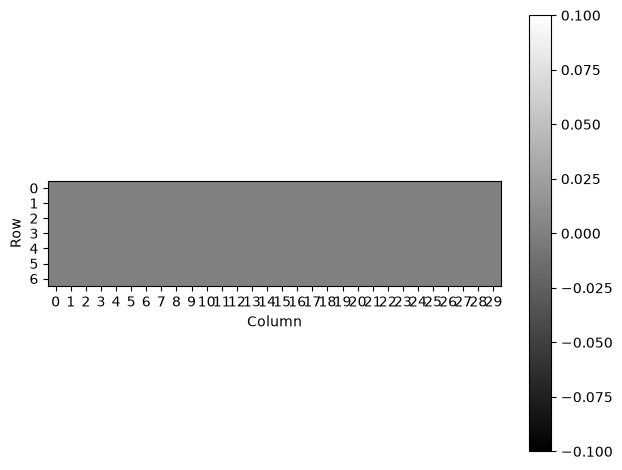

(A, 123)


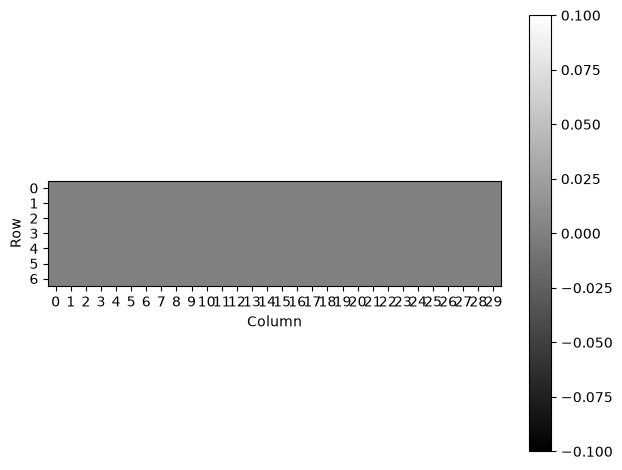

(A, 131)


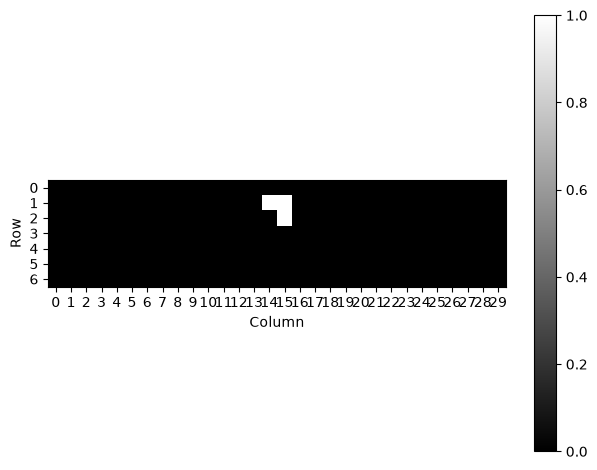

(A, 166)


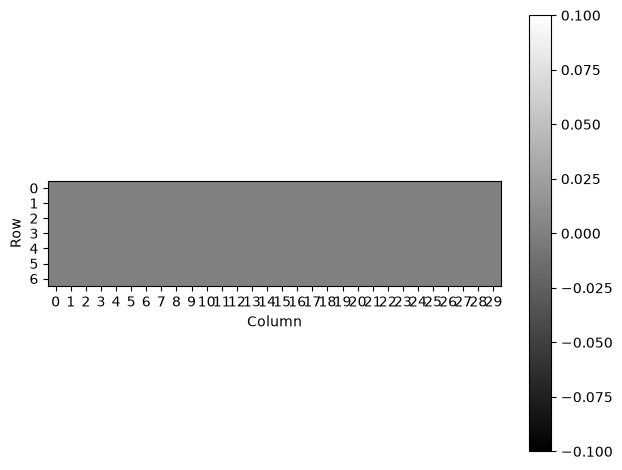

(A, 167)


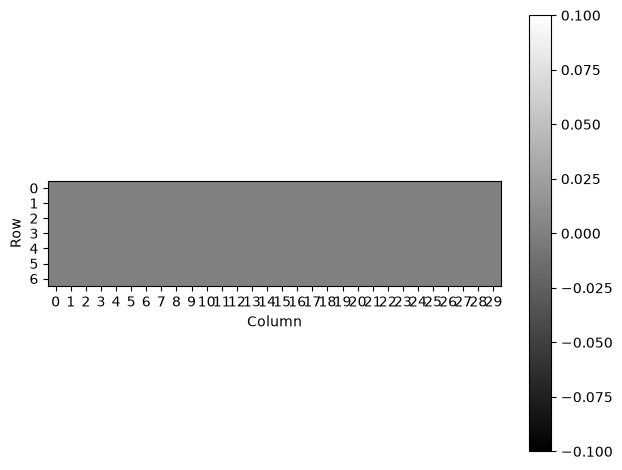

(A, 170)


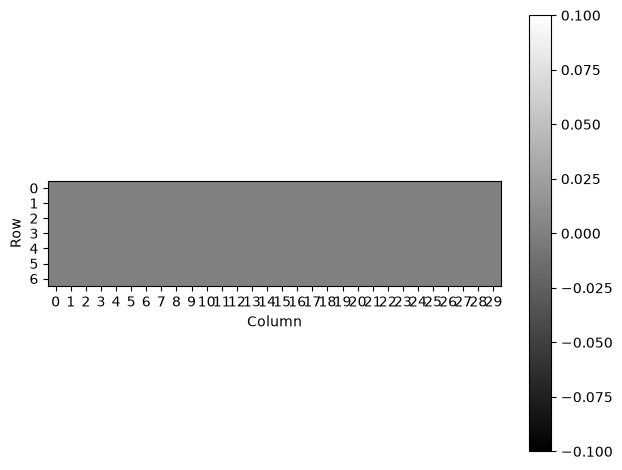

(A, 179)


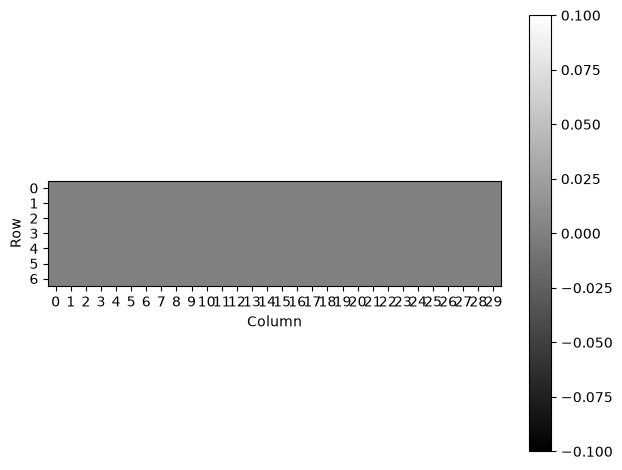

(A, 193)


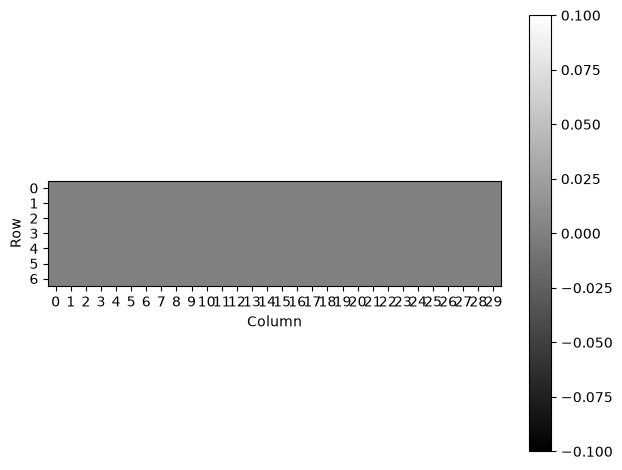

(A, 194)


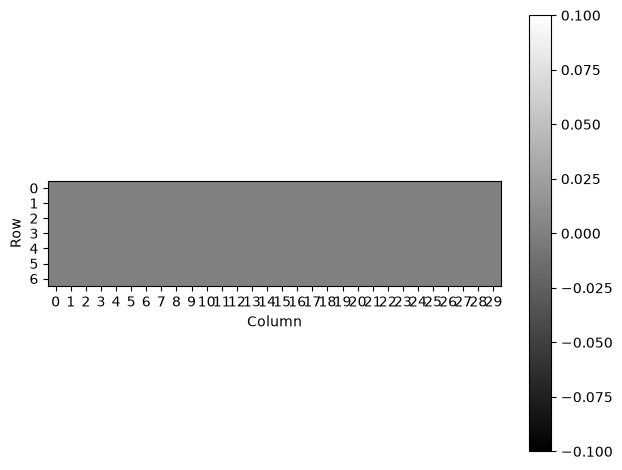

(A, 199)


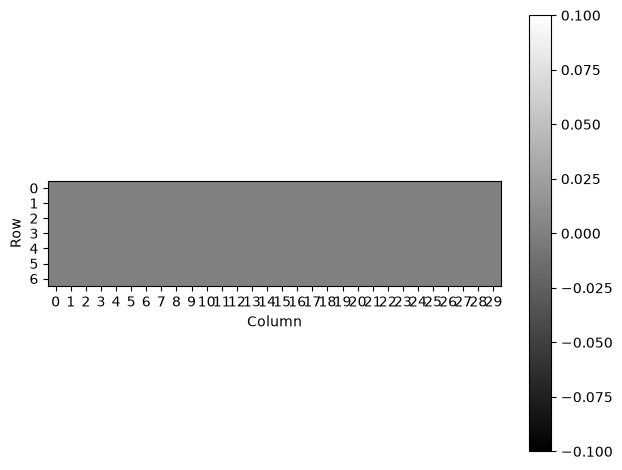

(A, 200)


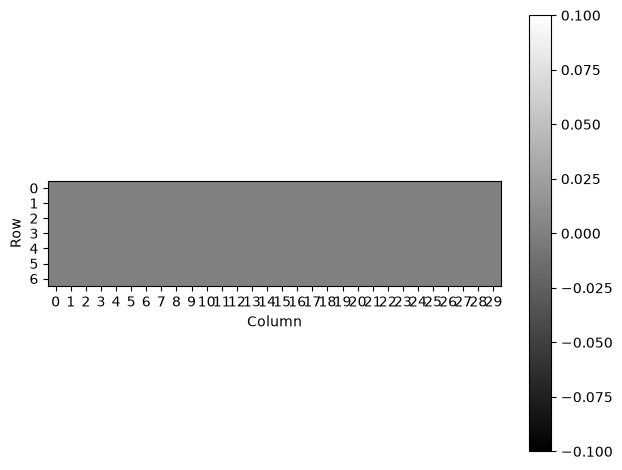

(A, 205)


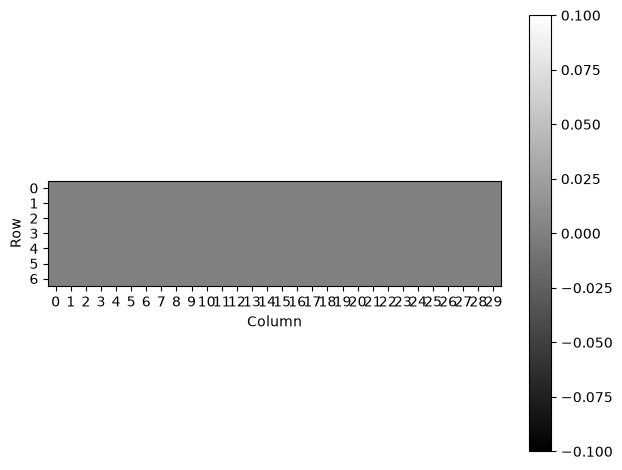

(A, 206)


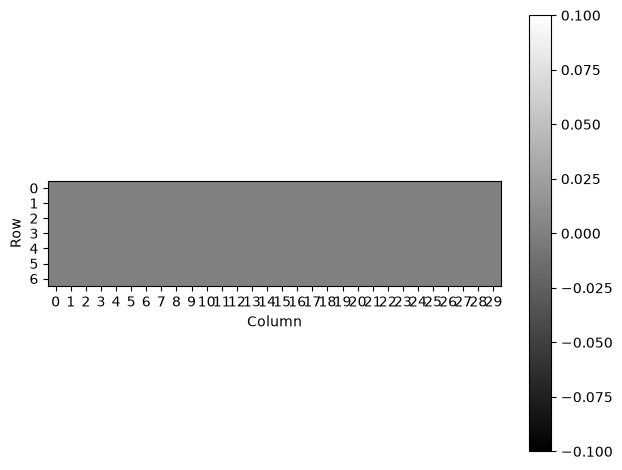

(A, 227)


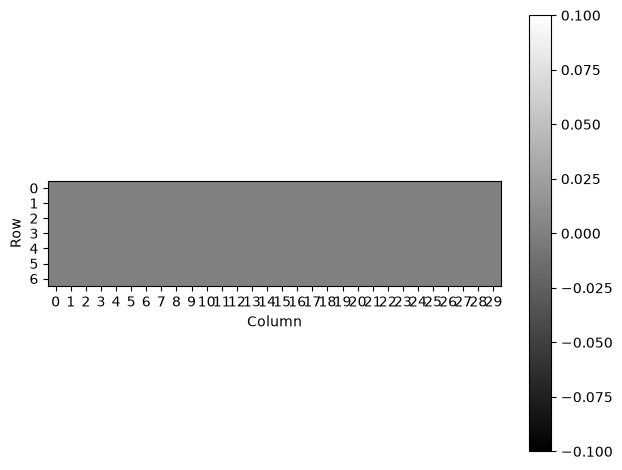

(A, 273)


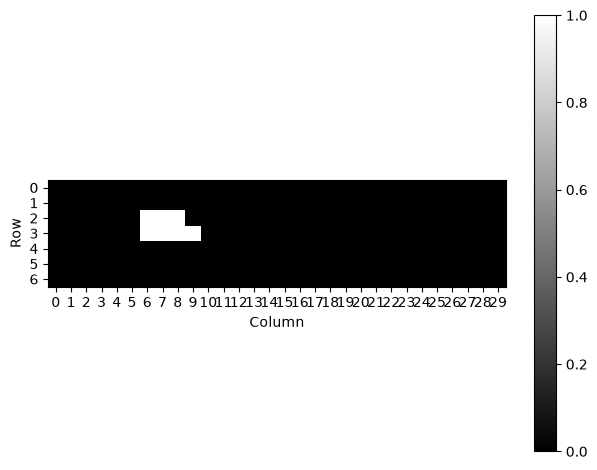

(A, 276)


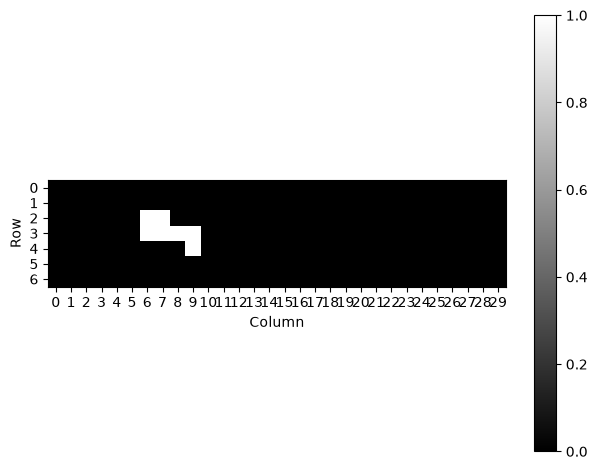

(A, 278)


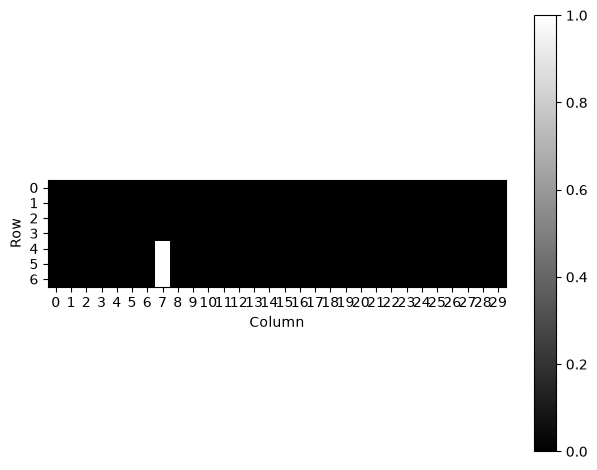

(A, 285)


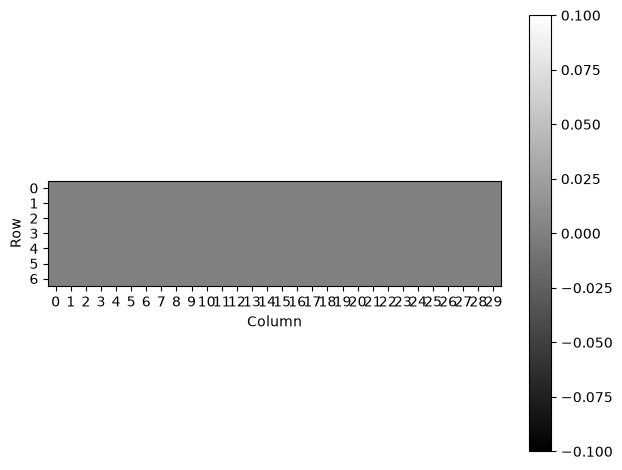

(A, 305)


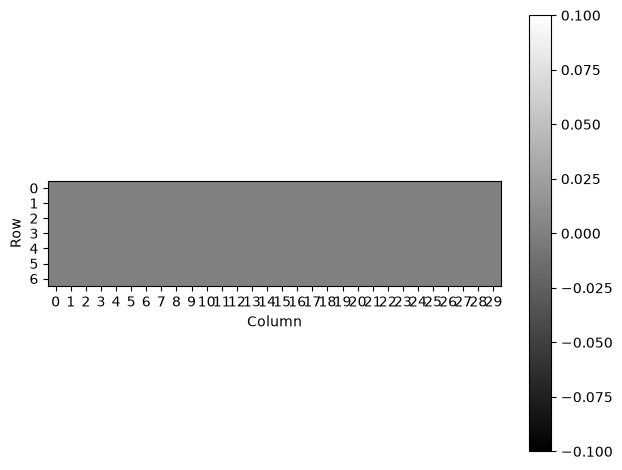

(A, 323)


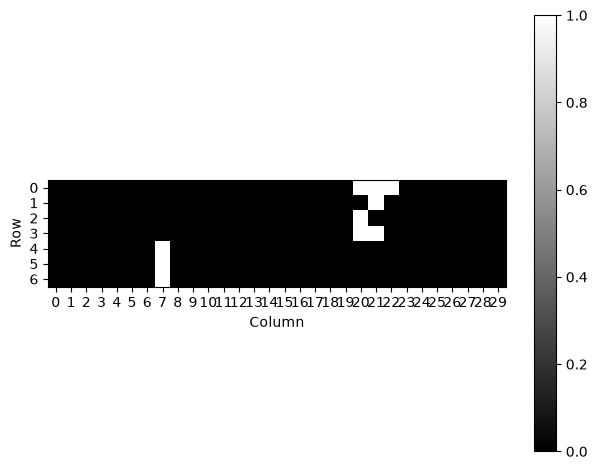

(A, 380)


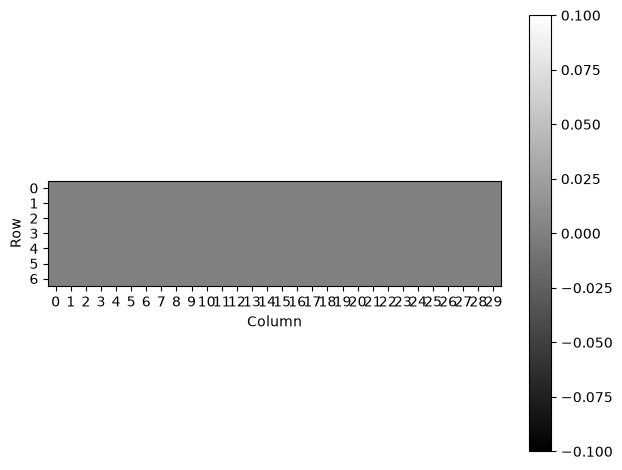

(A, 425)


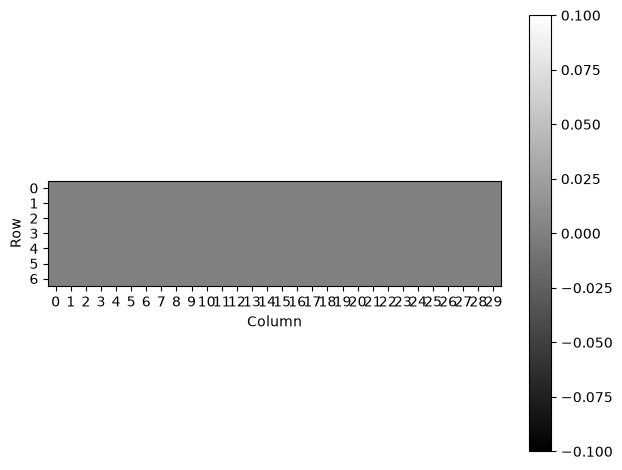

(A, 429)


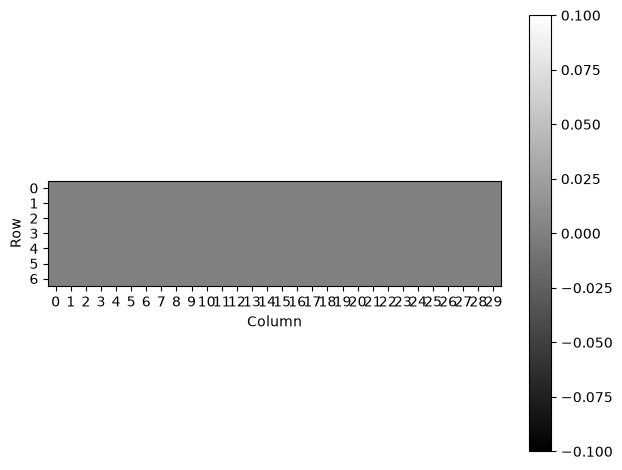

(A, 433)


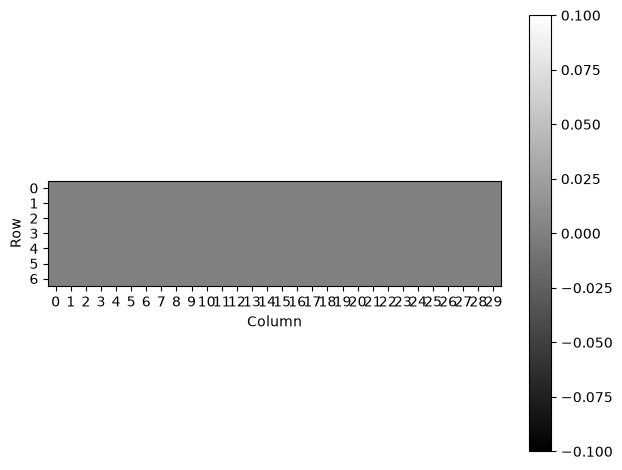

(A, 435)


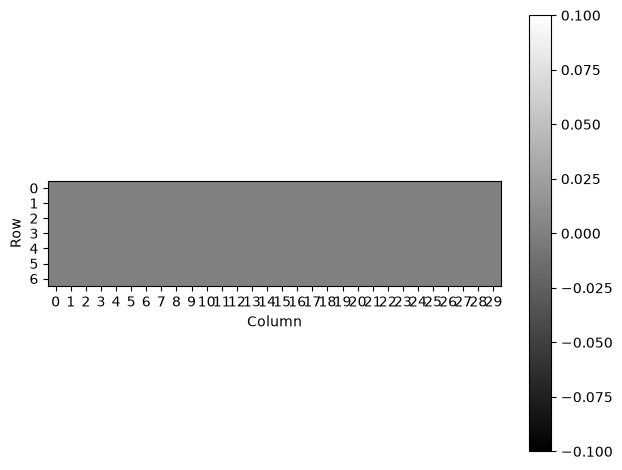

(A, 439)


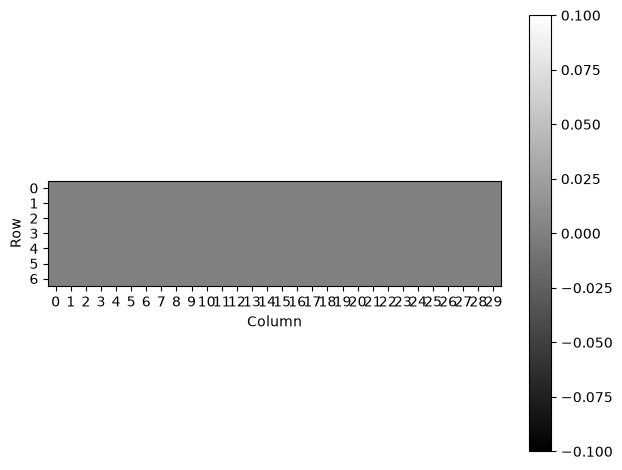

(A, 446)


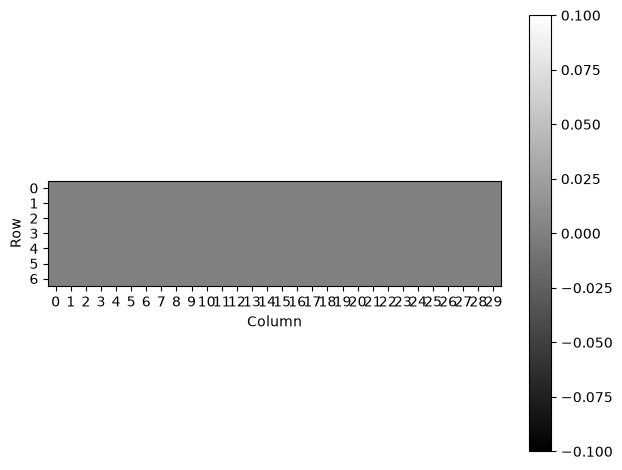

(A, 449)


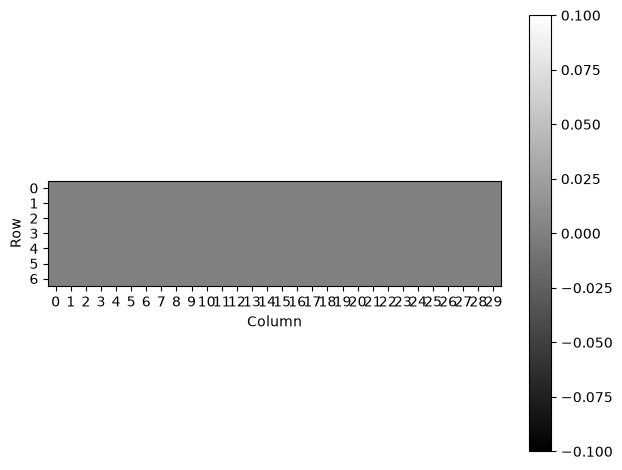

(A, 455)


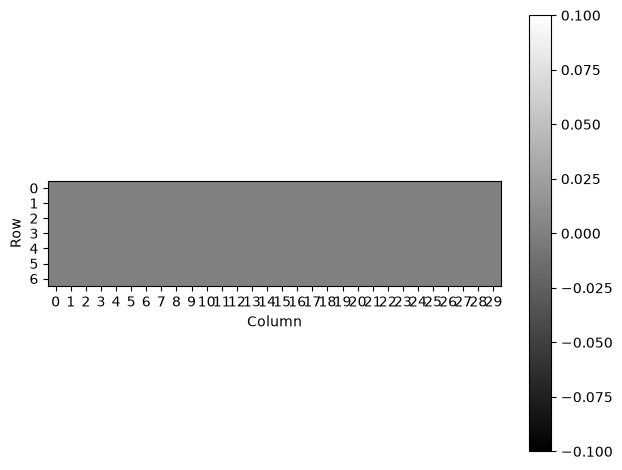

(A, 457)


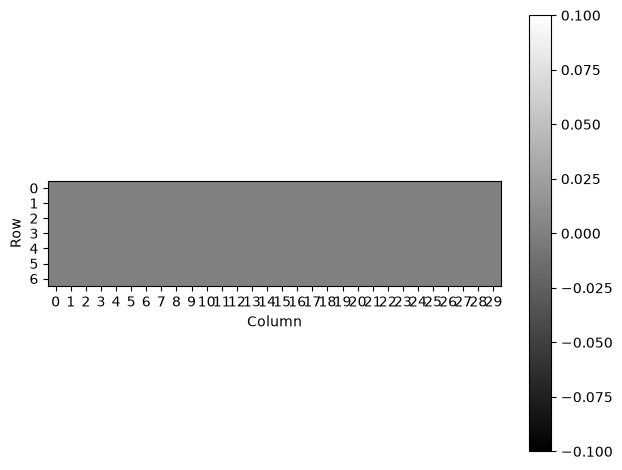

(A, 458)


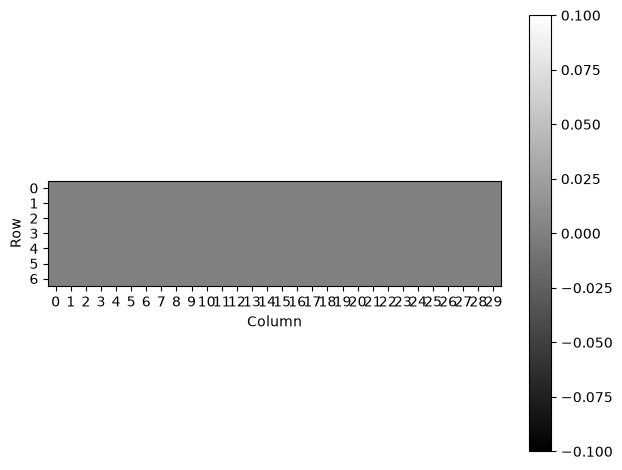

(A, 460)


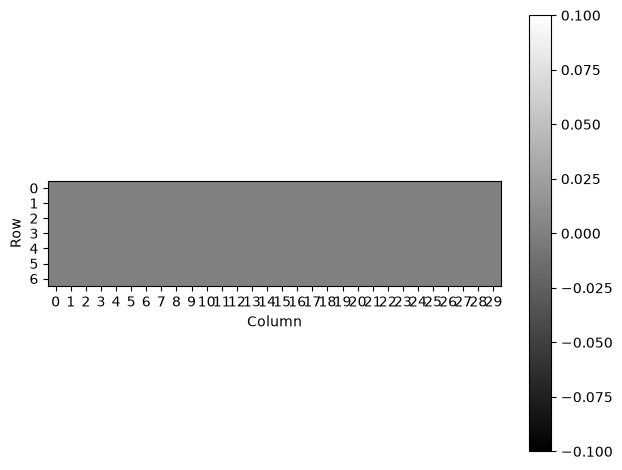

(A, 468)


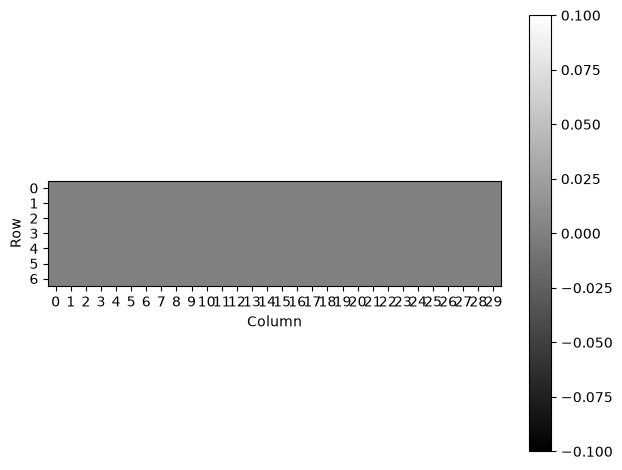

(A, 472)


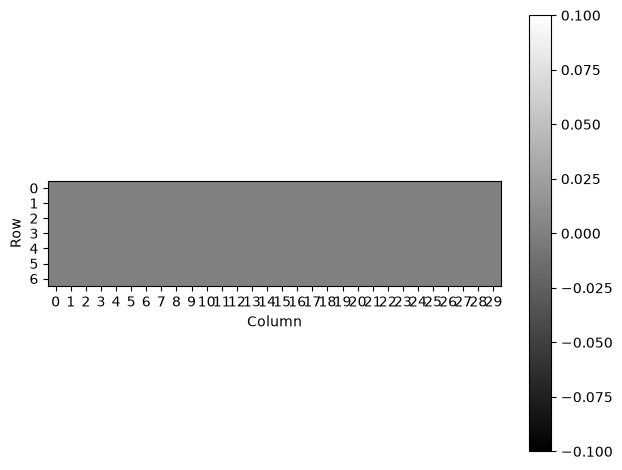

(A, 480)


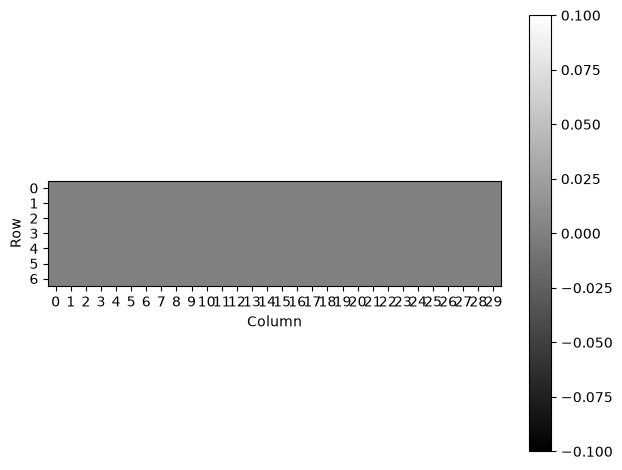

(A, 484)


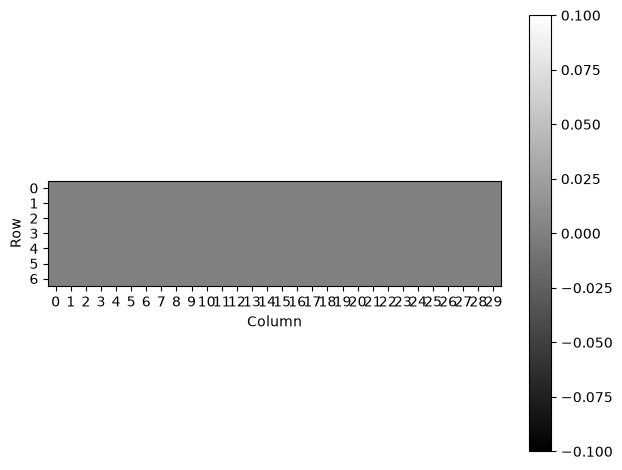

(A, 487)


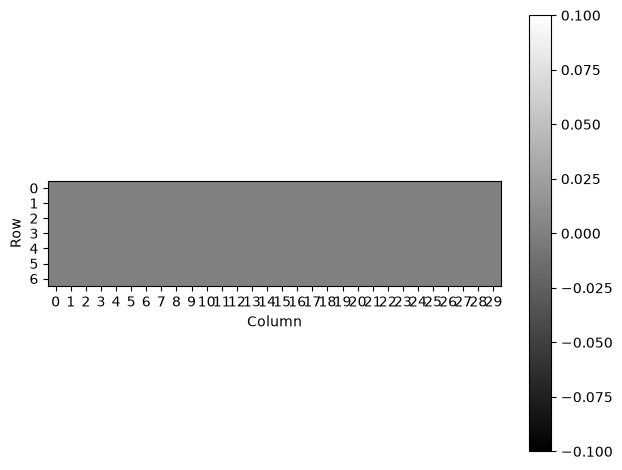

(A, 495)


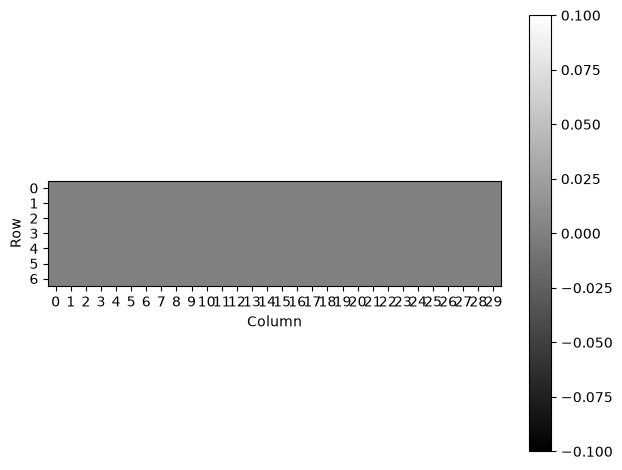

(A, 502)


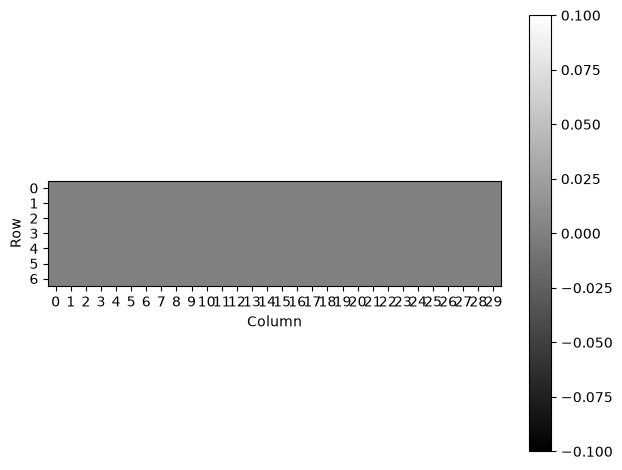

(A, 503)


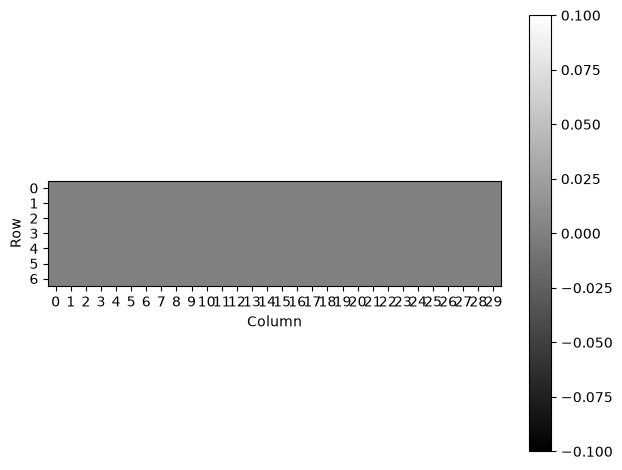

(A, 505)


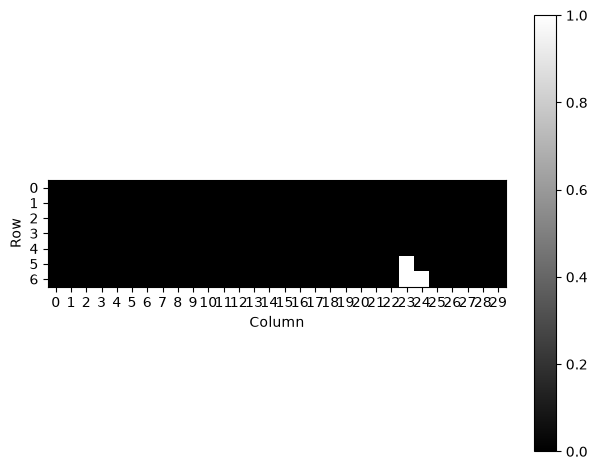

(A, 508)


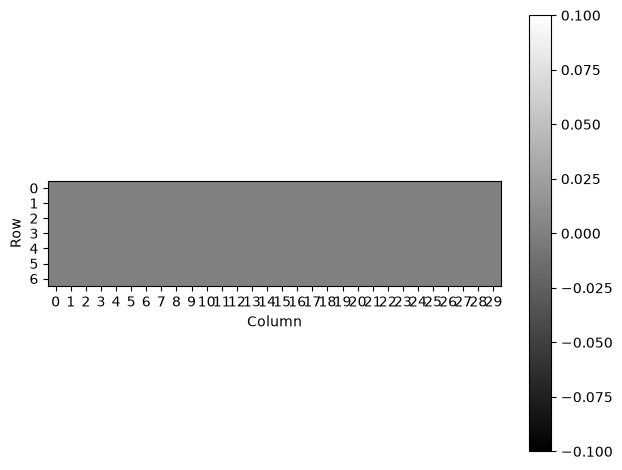

(A, 511)


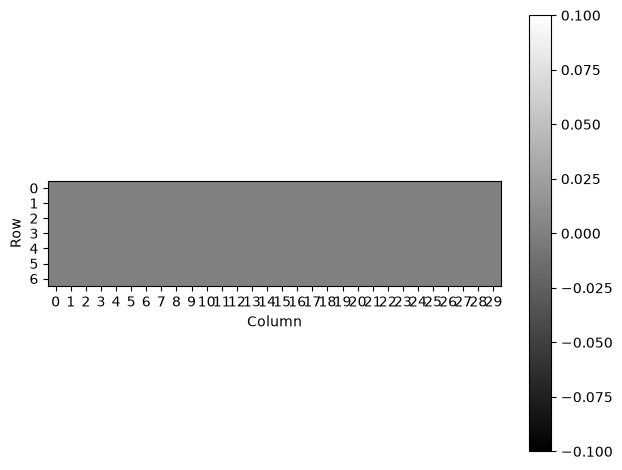

(A, 522)


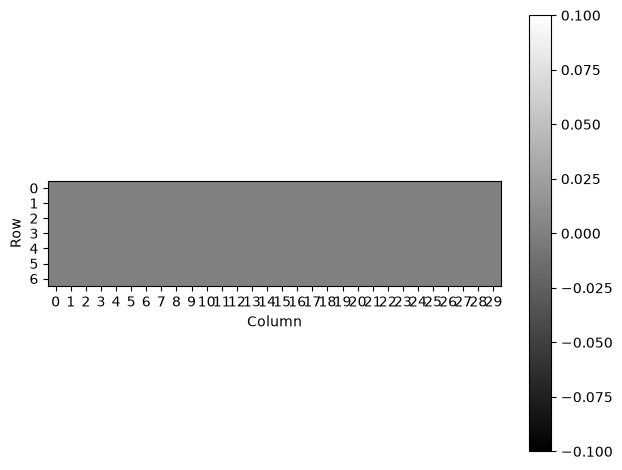

(A, 531)


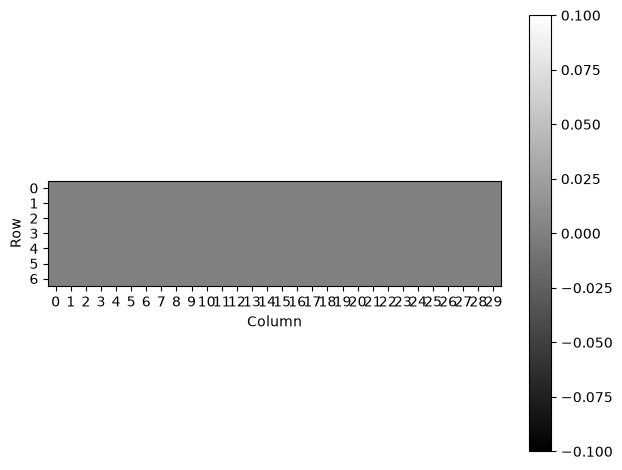

(A, 535)


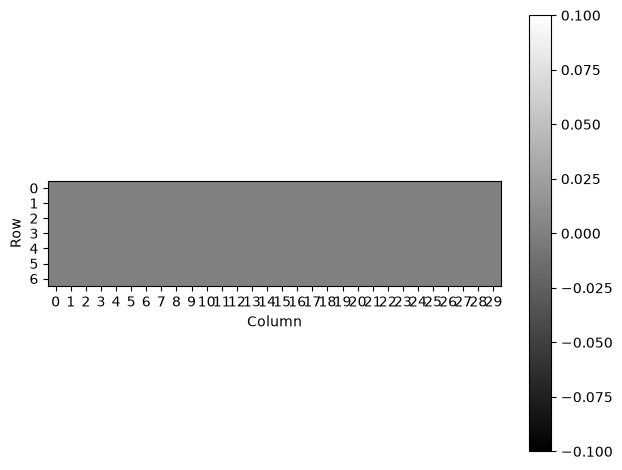

(A, 537)


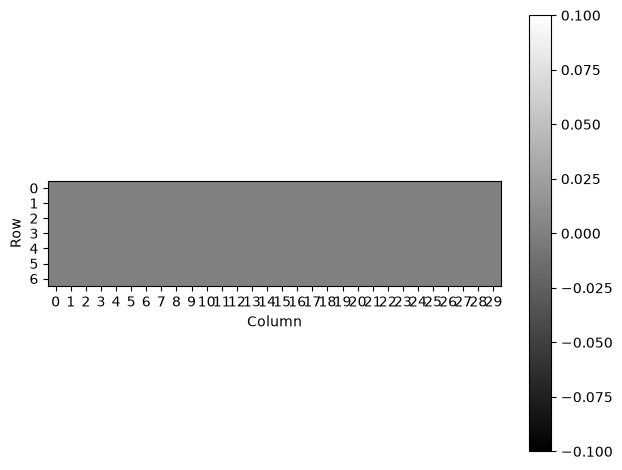

(A, 550)


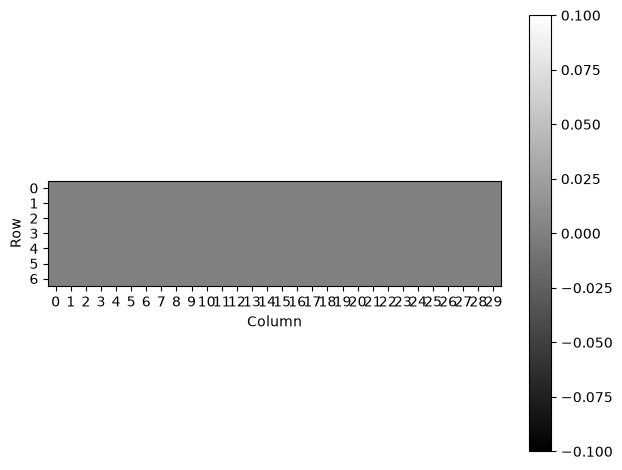

(A, 689)


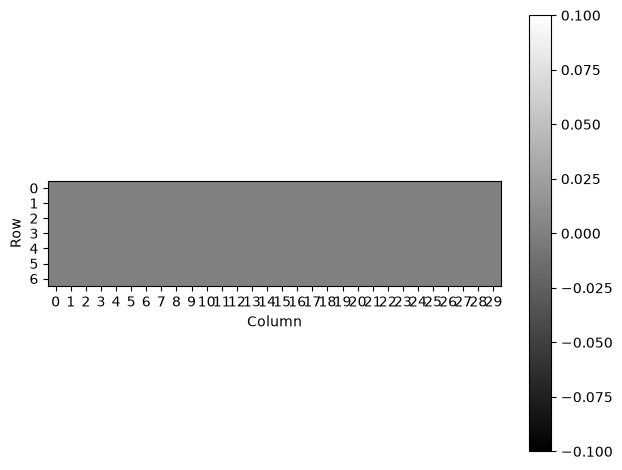

(A, 690)


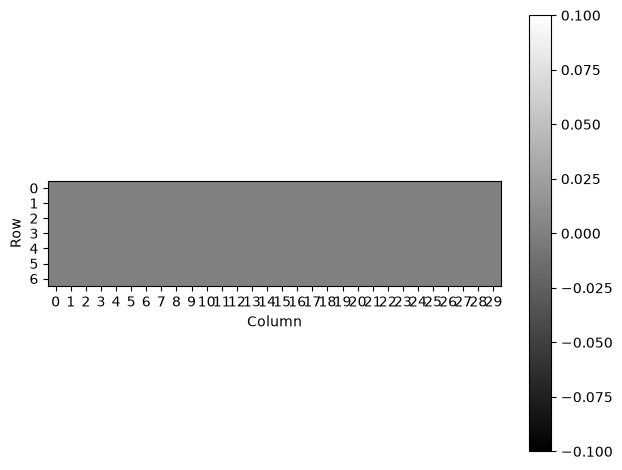

(A, 802)


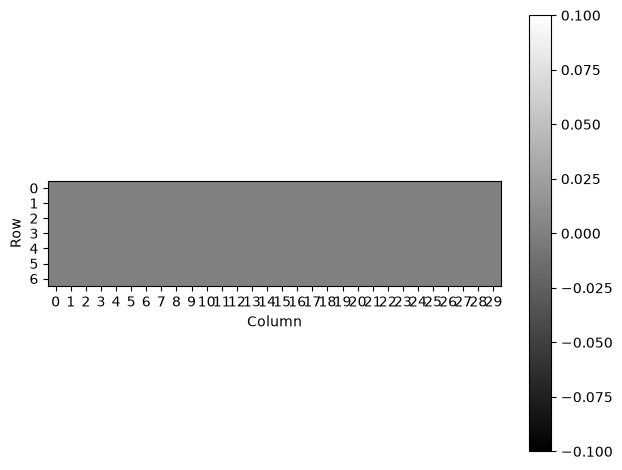

(A, 811)


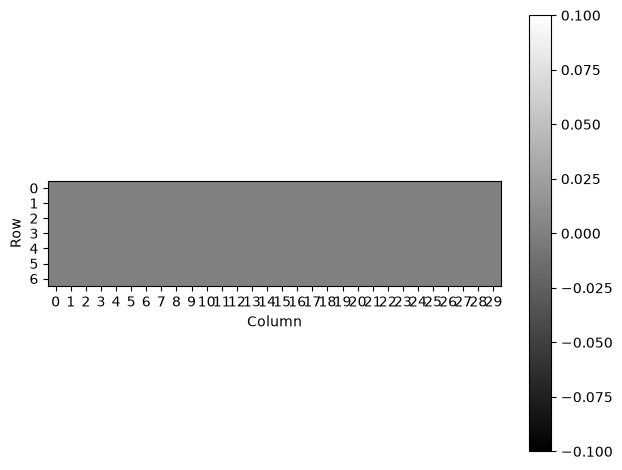

(A, 816)


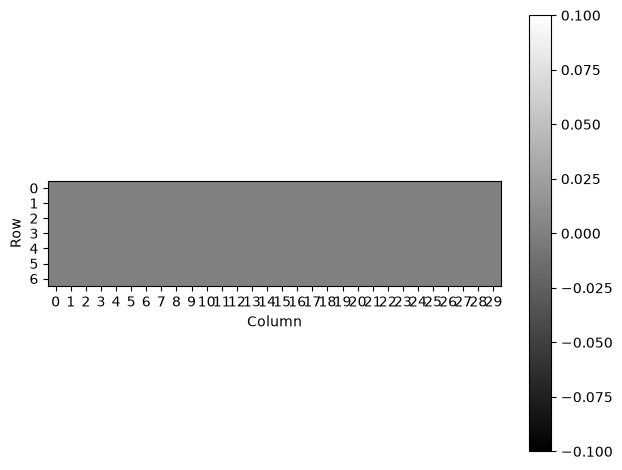

(A, 835)


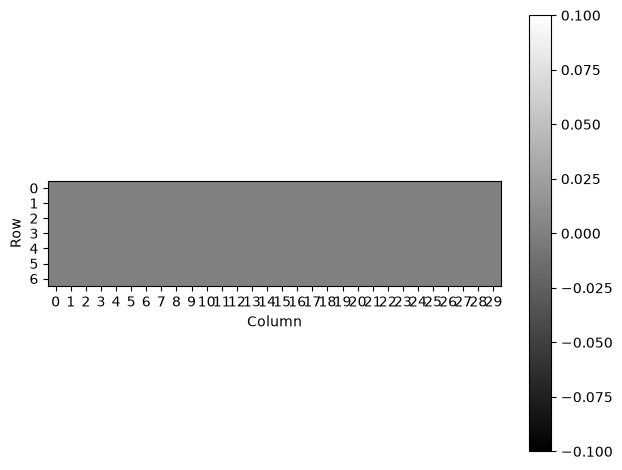

(A, 842)


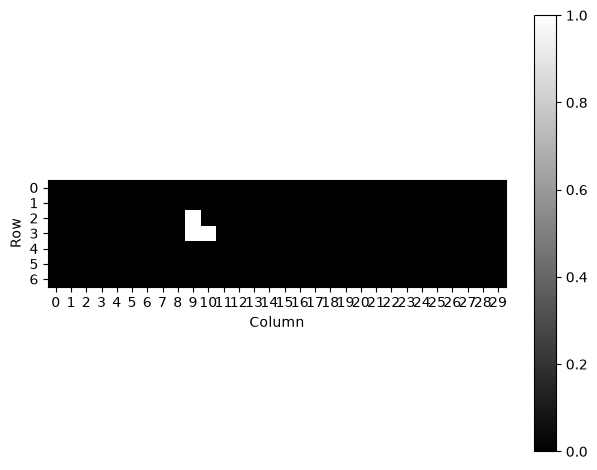

(A, 843)


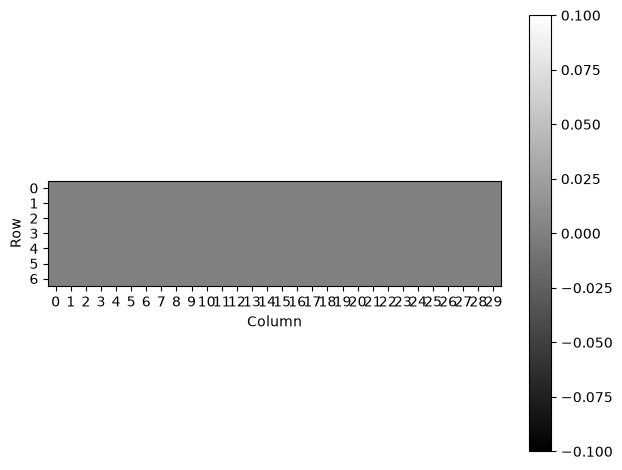

(A, 869)


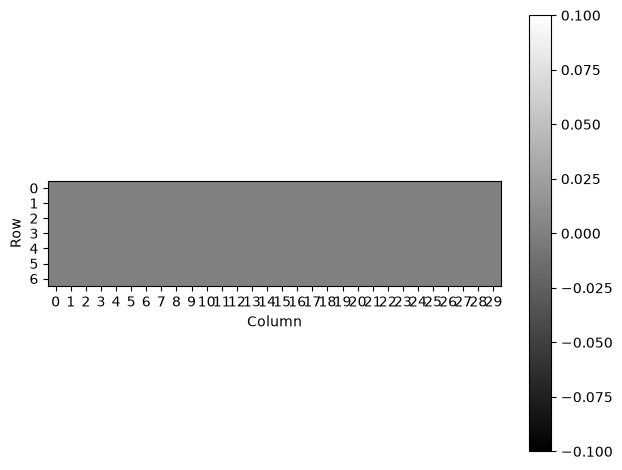

(A, 876)


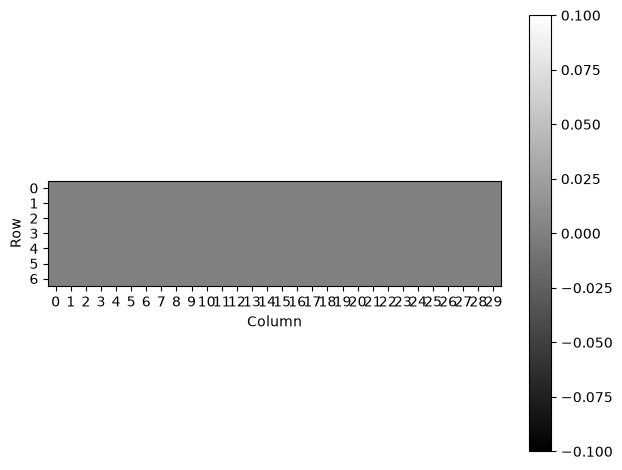

(A, 882)


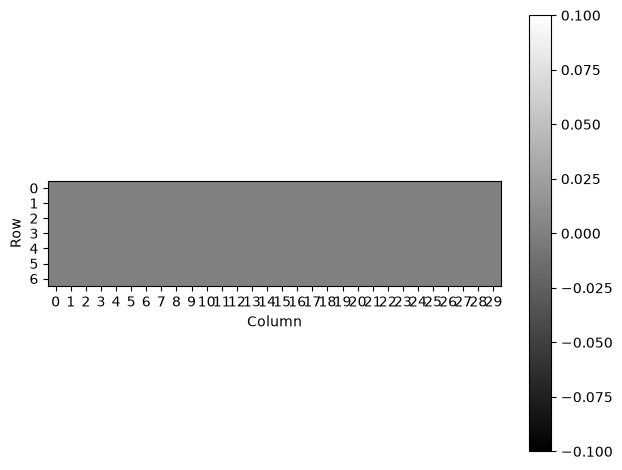

(A, 896)


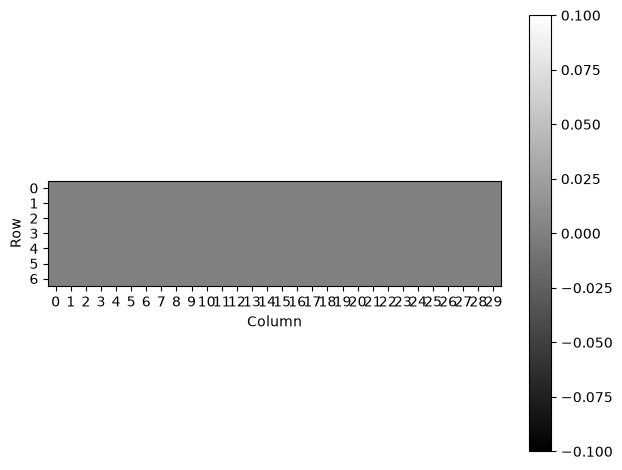

(A, 924)


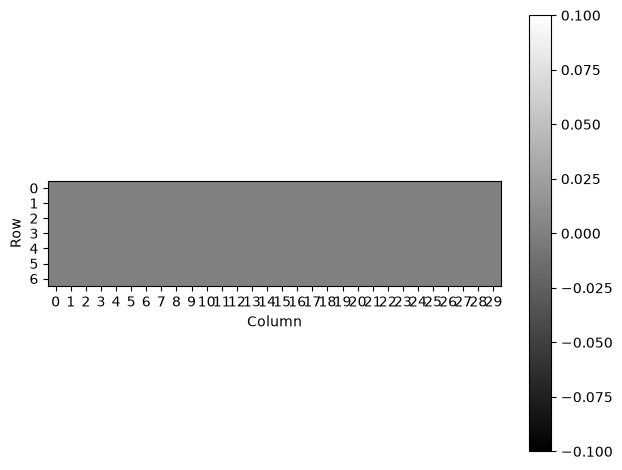

(A, 925)


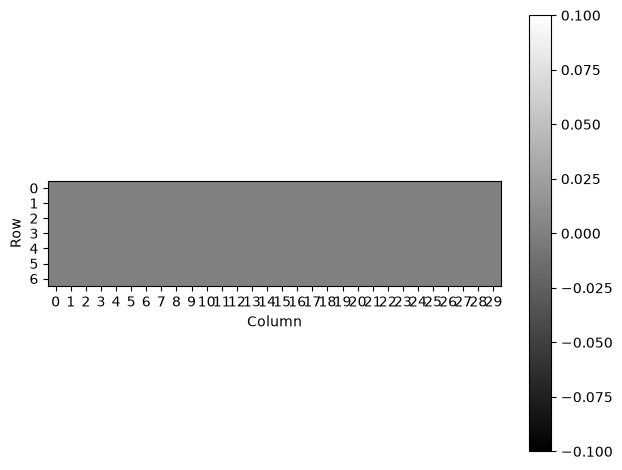

(A, 931)


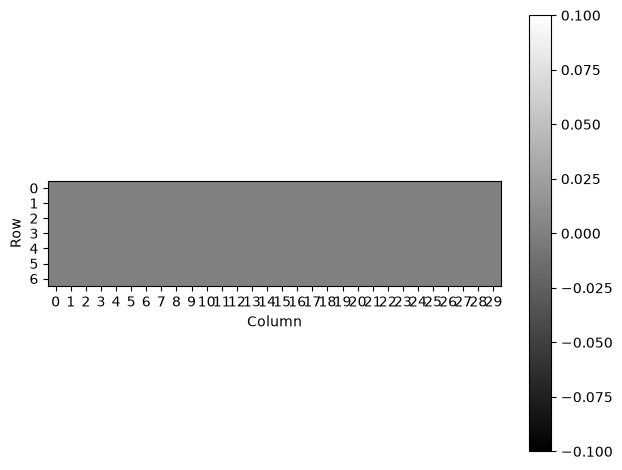

(A, 932)


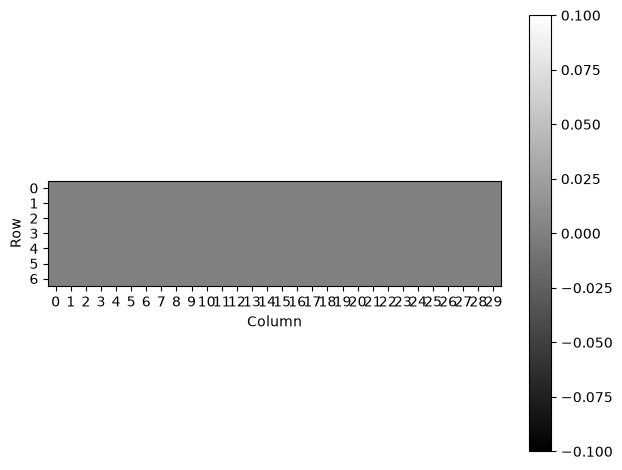

(A, 944)


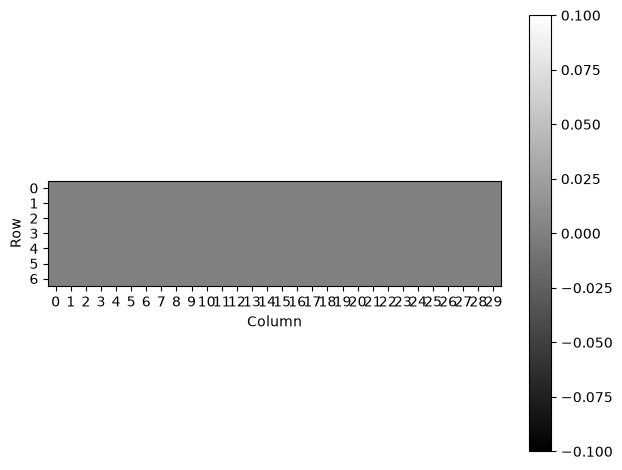

(A, 949)


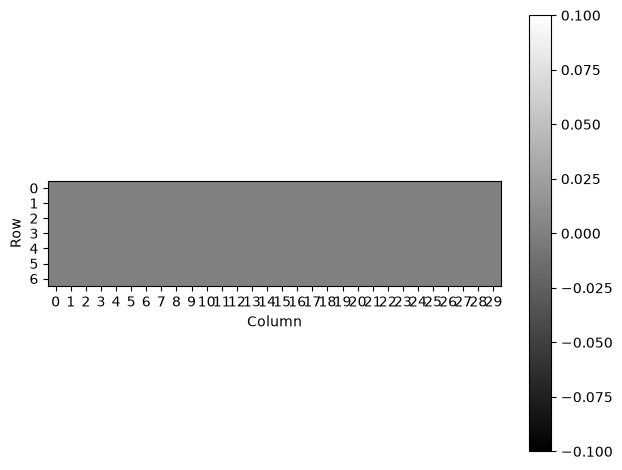

(A, 992)


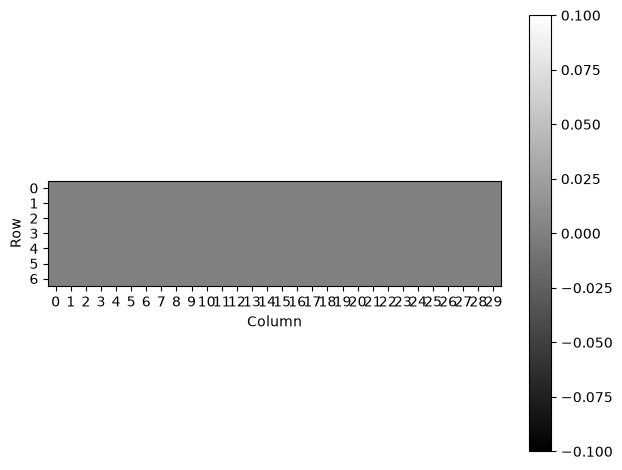

(A, 998)


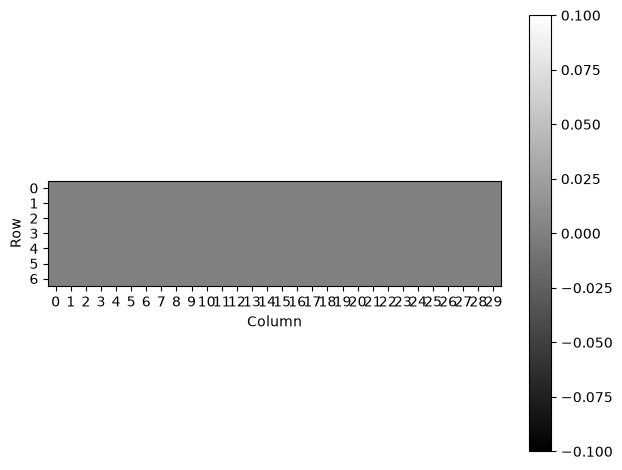

(A, 1050)


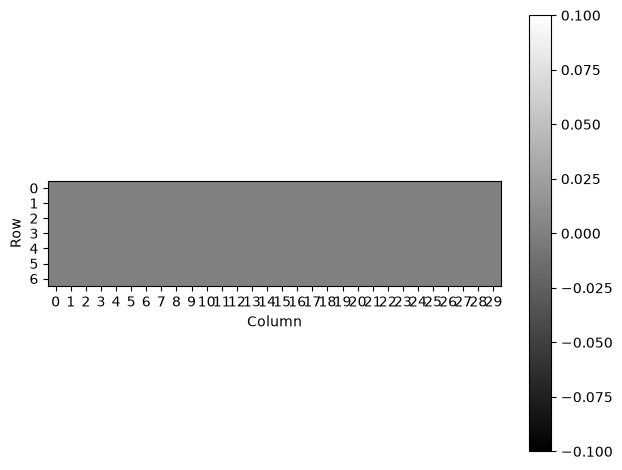

(A, 1106)


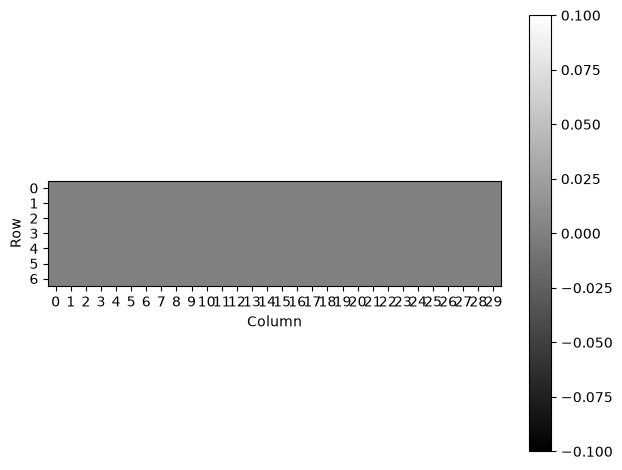

(A, 1127)


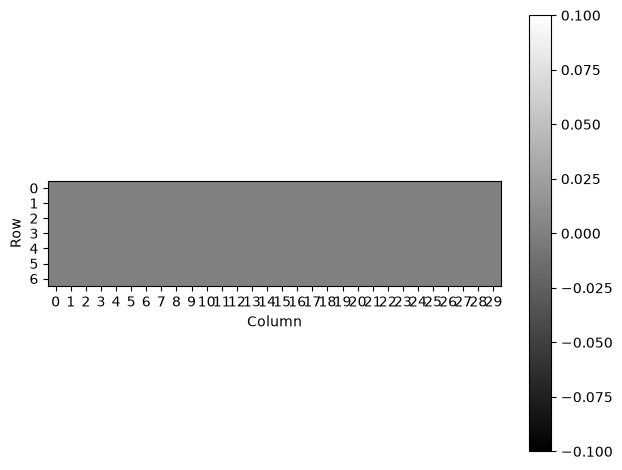

(A, 1134)


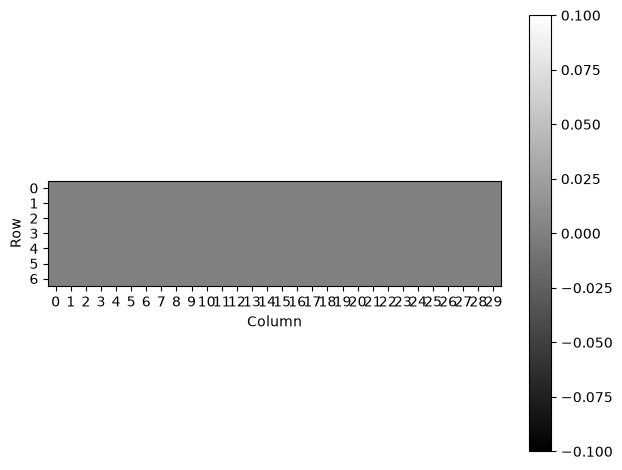

(A, 1156)


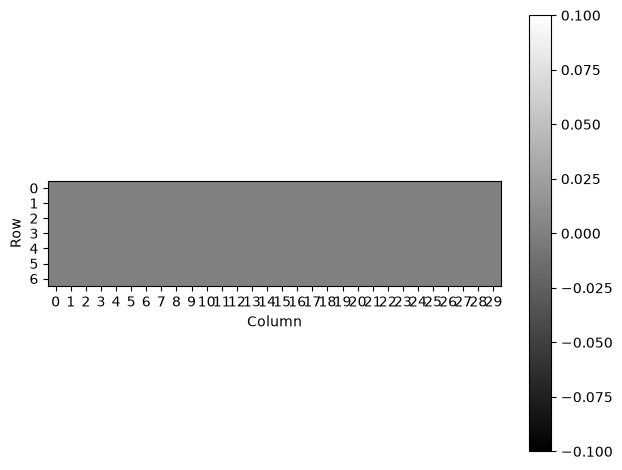

(A, 1158)


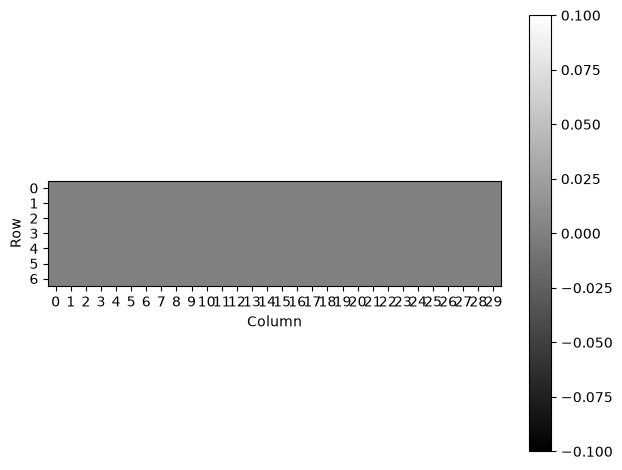

(A, 1176)


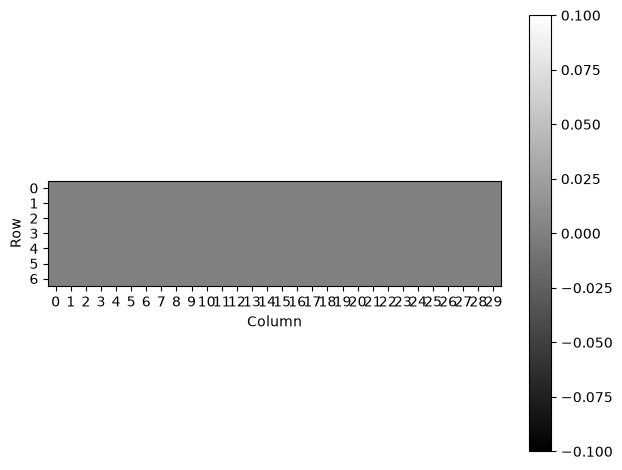

(A, 1177)


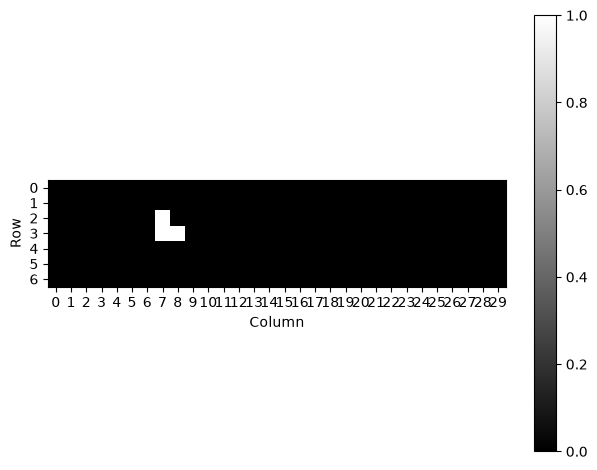

(A, 1208)


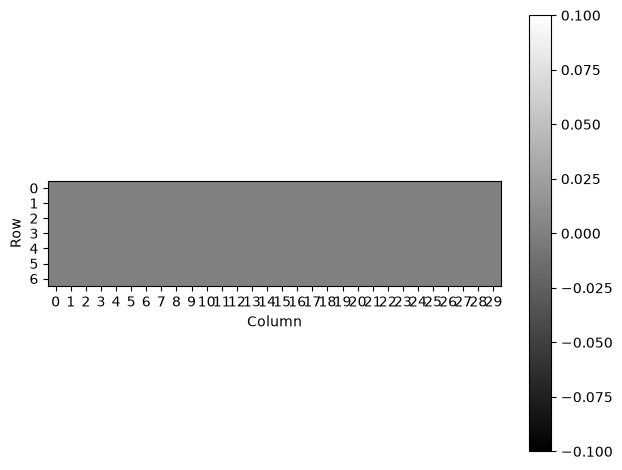

(A, 1217)


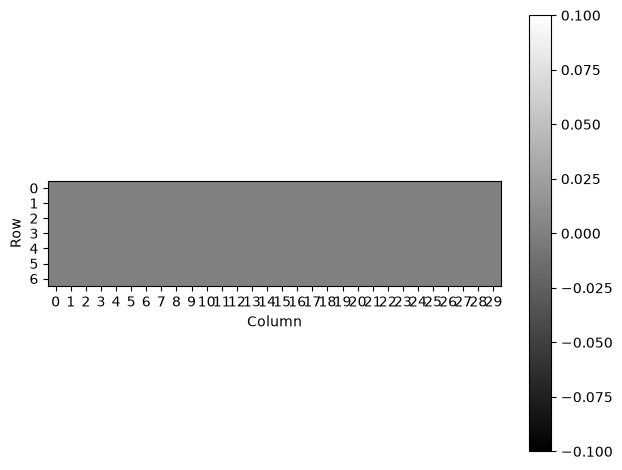

In [11]:
for index, rf in enumerate(rfs_by_probe[targetProbe]):
    probe, unit = RFunitPool[index]
    print(f"({probe}, {unit})")
    fig, _ = plot_2d_rfmap(rf, cmap="grey", is_save=is_save, save_path=f"{save_path}/rfmap/units/{probe}/{unit}.png")
    if is_save:
        fig.savefig(f"{save_path}/rfmap/units/{probe}/{unit}.svg", dpi=300, bbox_inches="tight")


------------ Probe A ------------


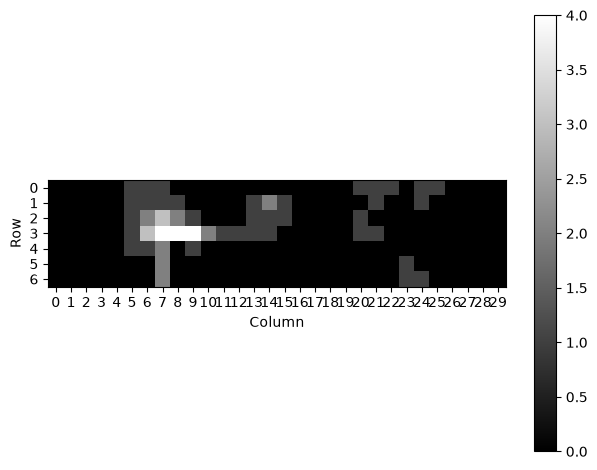

------------ All Probes ------------


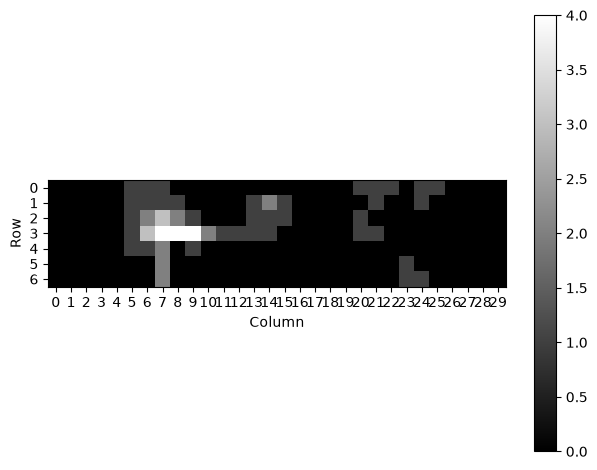

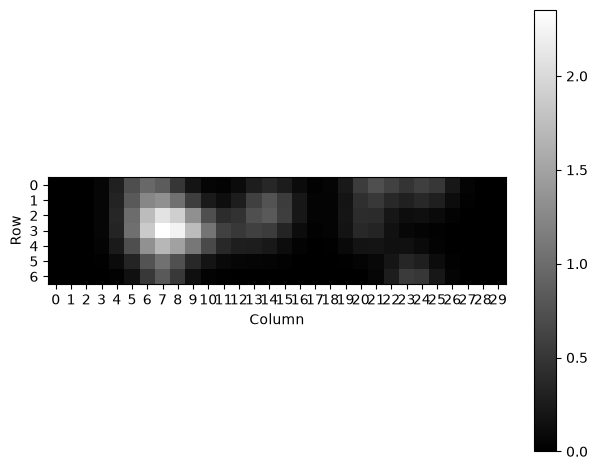

In [12]:
rf_counts_by_probe = {}
rf_counts = np.zeros(rf_all.shape[1:], dtype=np.int64)

for probe in probeList:
    probe_counts = rfs_by_probe[probe].sum(axis=0, dtype=np.int64)
    rf_counts_by_probe[probe] = probe_counts
    rf_counts += probe_counts
    print("------------ Probe", probe, "------------")
    fig, _ = plot_2d_rfmap(probe_counts, cmap="grey", is_save=is_save, save_path=f"{save_path}/rfmap/{probe}/rf.png")
    if is_save:
        fig.savefig(f"{save_path}/rfmap/{probe}/rf.svg", dpi=300, bbox_inches="tight")


rf_counts_smoothed = gaussian_filter(
    rf_counts.astype(float),
    sigma=(1.0, 1.0),
    mode="nearest",
)

print("------------ All Probes ------------")
fig, _ = plot_2d_rfmap(rf_counts, cmap="grey", is_save=is_save, save_path=f"{save_path}/rfmap/all/rf.png")
if is_save:
    fig.savefig(f"{save_path}/rfmap/all/rf.svg", dpi=300, bbox_inches="tight")

fig, _ = plot_2d_rfmap(rf_counts_smoothed, cmap="grey", is_save=is_save, save_path=f"{save_path}/rfmap/all/rf_smoothed.png")
if is_save:
    fig.savefig(f"{save_path}/rfmap/all/rf_smoothed.svg", dpi=300, bbox_inches="tight")


------------ Probe A ------------


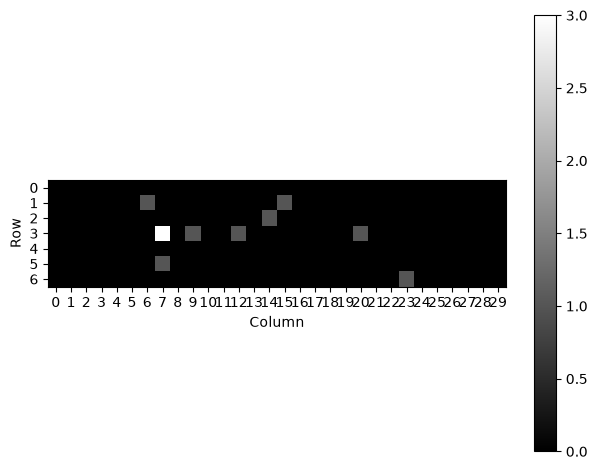

------------ All Probes ------------


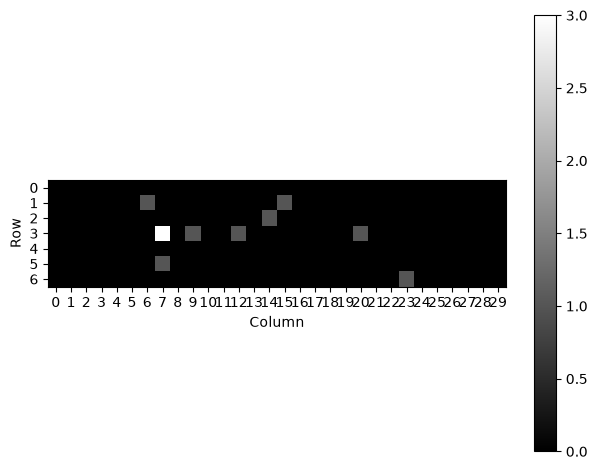

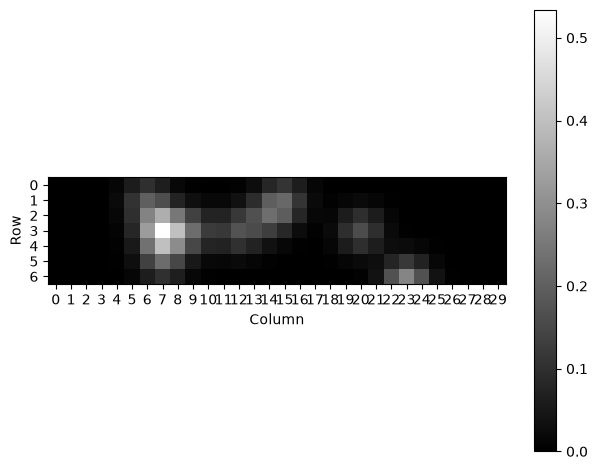

In [13]:
rf_counts_by_probe = {}
rf_counts = np.zeros(center_all.shape[1:], dtype=np.int64)

for probe in probeList:
    probe_counts = rf_centers_by_probe[probe].sum(axis=0, dtype=np.int64)
    rf_counts_by_probe[probe] = probe_counts
    rf_counts += probe_counts
    print("------------ Probe", probe, "------------")
    plot_2d_rfmap(probe_counts, cmap="grey")

rf_counts_smoothed = gaussian_filter(
    rf_counts.astype(float),
    sigma=(1.0, 1.0),
    mode="nearest",
)

print("------------ All Probes ------------")
fig, _ = plot_2d_rfmap(rf_counts, cmap="grey", is_save=is_save, save_path=f"{save_path}/rfmap/center/all/rf.png")
if is_save:
    fig.savefig(f"{save_path}/rfmap/center/all/rf.svg", dpi=300, bbox_inches="tight")

fig, _ = plot_2d_rfmap(rf_counts_smoothed, cmap="grey", is_save=is_save, save_path=f"{save_path}/rfmap/center/all/rf_smoothed.png")
if is_save:
    fig.savefig(f"{save_path}/rfmap/center/all/rf_smoothed.svg", dpi=300, bbox_inches="tight")

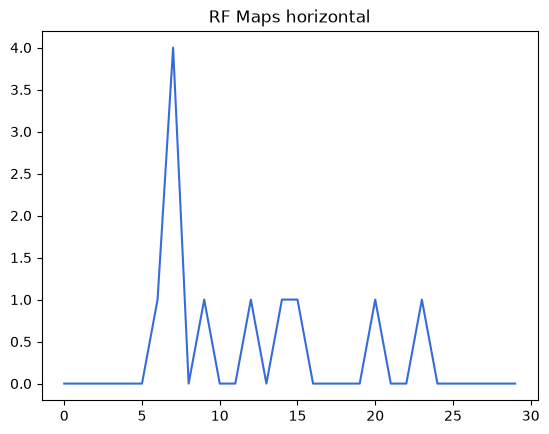

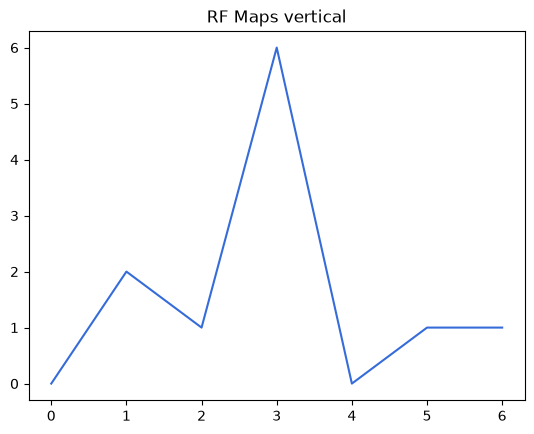

In [14]:
plt.plot(asrfmap(rf_counts).to_1d_array("x"))
plt.title("RF Maps horizontal")
if is_save:
    plt.savefig(f"{save_path}/rfmap/all/horizontal.png")
plt.show()
plt.plot(asrfmap(rf_counts).to_1d_array("y"))
plt.title("RF Maps vertical")
if is_save:
    plt.savefig(f"{save_path}/rfmap/all/vertical.png")
plt.show()
